In [2]:
#Importing the Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
# Load the audit risk dataset
df = pd.read_csv('audit_risk.csv')

In [4]:
# Quick check
print("Dataset shape:", df.shape)
print("\nFirst few rows:")
print(df.head())
print("\nColumn names:")
print(df.columns.tolist())

Dataset shape: (776, 27)

First few rows:
   Sector_score LOCATION_ID  PARA_A  Score_A  Risk_A  PARA_B  Score_B  Risk_B  \
0          3.89          23    4.18      0.6   2.508    2.50      0.2   0.500   
1          3.89           6    0.00      0.2   0.000    4.83      0.2   0.966   
2          3.89           6    0.51      0.2   0.102    0.23      0.2   0.046   
3          3.89           6    0.00      0.2   0.000   10.80      0.6   6.480   
4          3.89           6    0.00      0.2   0.000    0.08      0.2   0.016   

   TOTAL  numbers  ...  RiSk_E  History  Prob  Risk_F  Score  Inherent_Risk  \
0   6.68      5.0  ...     0.4        0   0.2     0.0    2.4          8.574   
1   4.83      5.0  ...     0.4        0   0.2     0.0    2.0          2.554   
2   0.74      5.0  ...     0.4        0   0.2     0.0    2.0          1.548   
3  10.80      6.0  ...     0.4        0   0.2     0.0    4.4         17.530   
4   0.08      5.0  ...     0.4        0   0.2     0.0    2.0          1.416 

In [10]:
# THE CRITICAL QUESTION:
# Which features differ between high-risk and low-risk firms?

# Step 1: Split the data by risk level
comparison = df.groupby('Risk').mean(numeric_only=True)
print("=" * 80)
print("AVERAGE VALUES: High-Risk (1) vs Low-Risk (0) Firms")
print("=" * 80)
print(comparison)
print("\n")

# Step 2: Find the BIGGEST differences
print("=" * 80)
print("DIFFERENCES (High-Risk MINUS Low-Risk)")
print("=" * 80)
differences = comparison.loc[1] - comparison.loc[0]
differences_sorted = differences.abs().sort_values(ascending=False)
print(differences_sorted)

AVERAGE VALUES: High-Risk (1) vs Low-Risk (0) Firms
      Sector_score    PARA_A   Score_A    Risk_A     PARA_B   Score_B  \
Risk                                                                    
0        27.892611  0.720446  0.264544  0.285635   0.447667  0.226327   
1         8.281246  5.121379  0.485246  2.996276  26.786689  0.447213   

         Risk_B      TOTAL   numbers  Score_B.1  ...      PROB    RiSk_E  \
Risk                                             ...                       
0      0.160085   1.168113  5.002123   0.200849  ...  0.200849  0.422930   
1     15.868164  31.827412  5.168852   0.259016  ...  0.214426  0.667541   

       History      Prob    Risk_F     Score  Inherent_Risk  CONTROL_RISK  \
Risk                                                                        
0     0.002123  0.200425  0.000849  2.159660       1.964002      0.423779   
1     0.262295  0.241967  0.135082  3.540984      41.951181      0.802623   

      Detection_Risk  Audit_Risk  
Risk  

In [12]:
# Let's be VERY specific
print("\n" + "=" * 80)
print("TOP 5 DIFFERENTIATING FEATURES")
print("=" * 80)

top_5_features = differences_sorted.head(5)
for feature, diff in top_5_features.items():
    low_risk_avg = comparison.loc[0, feature]
    high_risk_avg = comparison.loc[1, feature]
    print(f"\n{feature}")
    print(f"  Low-risk avg:  {low_risk_avg:.4f}")
    print(f"  High-risk avg: {high_risk_avg:.4f}")
    print(f"  Difference:    {diff:.4f}")
    print(f"  → High-risk firms have {abs(diff):.2f} {'higher' if diff > 0 else 'lower'} values")


TOP 5 DIFFERENTIATING FEATURES

Inherent_Risk
  Low-risk avg:  1.9640
  High-risk avg: 41.9512
  Difference:    39.9872
  → High-risk firms have 39.99 higher values

Money_Value
  Low-risk avg:  0.3574
  High-risk avg: 35.3728
  Difference:    35.0154
  → High-risk firms have 35.02 higher values

TOTAL
  Low-risk avg:  1.1681
  High-risk avg: 31.8274
  Difference:    30.6593
  → High-risk firms have 30.66 higher values

PARA_B
  Low-risk avg:  0.4477
  High-risk avg: 26.7867
  Difference:    26.3390
  → High-risk firms have 26.34 higher values

Risk_D
  Low-risk avg:  0.0894
  High-risk avg: 20.8914
  Difference:    20.8020
  → High-risk firms have 20.80 higher values


/tmp/ipykernel_7211/3108824512.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data_to_plot, labels=['Low-Risk (0)', 'High-Risk (1)'])
/tmp/ipykernel_7211/3108824512.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data_to_plot, labels=['Low-Risk (0)', 'High-Risk (1)'])
/tmp/ipykernel_7211/3108824512.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data_to_plot, labels=['Low-Risk (0)', 'High-Risk (1)'])
/tmp/ipykernel_7211/3108824512.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the

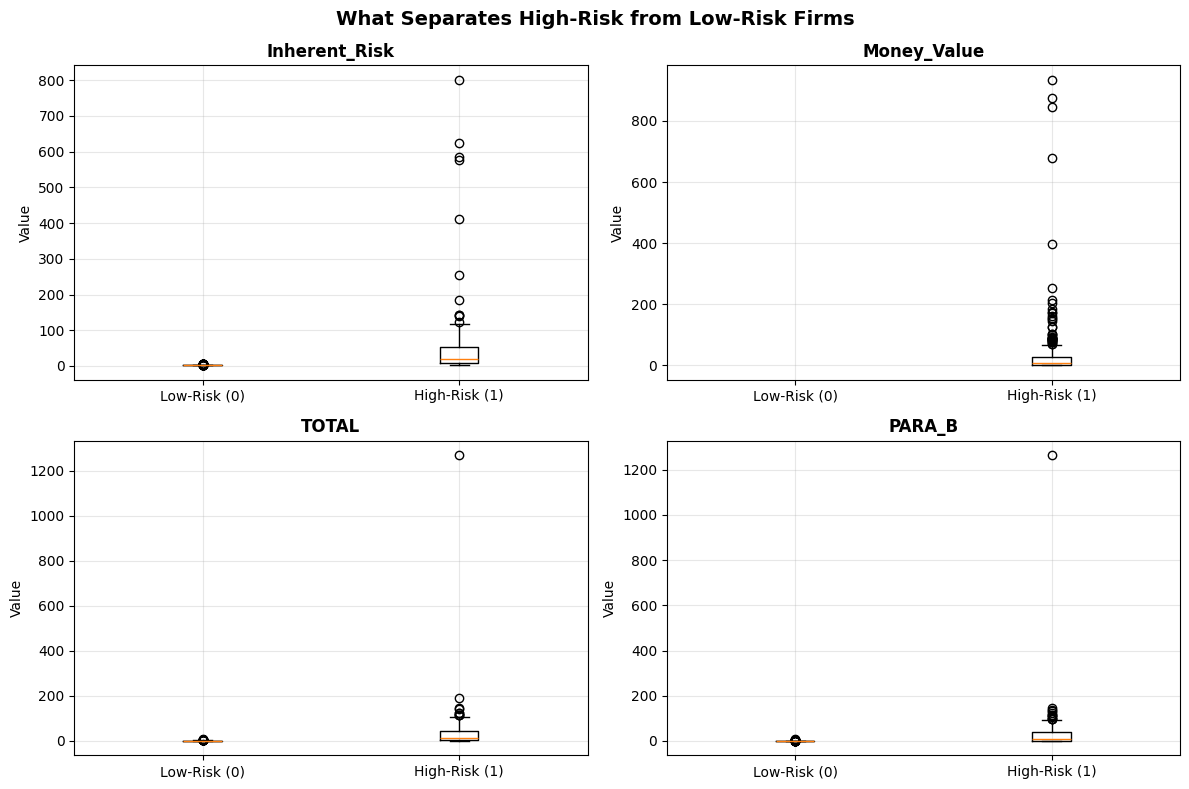


✅ Visualizations show the CLEAR SEPARATION between groups
   → This is what supervised learning learns from!


In [13]:
# Visualize the top differences
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle('What Separates High-Risk from Low-Risk Firms', fontsize=14, fontweight='bold')

# Get top 4 features
top_features = differences_sorted.head(4).index.tolist()

for idx, feature in enumerate(top_features):
    ax = axes[idx // 2, idx % 2]

    # Create boxplot showing distribution for each risk level
    data_to_plot = [df[df['Risk'] == 0][feature], df[df['Risk'] == 1][feature]]
    ax.boxplot(data_to_plot, labels=['Low-Risk (0)', 'High-Risk (1)'])
    ax.set_title(feature, fontweight='bold')
    ax.set_ylabel('Value')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n✅ Visualizations show the CLEAR SEPARATION between groups")
print("   → This is what supervised learning learns from!")

In [14]:
# YOUR FINDINGS
print("\n" + "=" * 80)
print("HOUR 2 KEY FINDINGS")
print("=" * 80)

print(f"\n📊 Dataset: {len(df)} firms")
print(f"   • {len(df[df['Risk']==1])} high-risk (39.3%)")
print(f"   • {len(df[df['Risk']==0])} low-risk (60.7%)")

print(f"\n🎯 Top 3 Features That Separate High-Risk from Low-Risk:")
for i, (feature, diff) in enumerate(differences_sorted.head(3).items(), 1):
    print(f"   {i}. {feature} (difference: {diff:.4f})")

print(f"\n💡 What This Means:")
print(f"   → A supervised learning model WOULD USE these features to predict risk")
print(f"   → If we see a NEW firm with values similar to the high-risk pattern,")
print(f"      we'd predict it's high-risk")

print(f"\n✅ This is supervised learning in action!")


HOUR 2 KEY FINDINGS

📊 Dataset: 776 firms
   • 305 high-risk (39.3%)
   • 471 low-risk (60.7%)

🎯 Top 3 Features That Separate High-Risk from Low-Risk:
   1. Inherent_Risk (difference: 39.9872)
   2. Money_Value (difference: 35.0154)
   3. TOTAL (difference: 30.6593)

💡 What This Means:
   → A supervised learning model WOULD USE these features to predict risk
   → If we see a NEW firm with values similar to the high-risk pattern,
      we'd predict it's high-risk

✅ This is supervised learning in action!


In [15]:
print("\n" + "=" * 80)
print("HOUR 2 COMPLETE ✅")
print("=" * 80)
print("\nWhat you discovered:")
print("1. High-risk and low-risk firms are MEASURABLY different")
print("2. Specific features distinguish them clearly")
print("3. A supervised model would learn: 'When these features look like this → predict high-risk'")
print("4. This is exactly what your supervised learning (revenue testing) example does!")


HOUR 2 COMPLETE ✅

What you discovered:
1. High-risk and low-risk firms are MEASURABLY different
2. Specific features distinguish them clearly
3. A supervised model would learn: 'When these features look like this → predict high-risk'
4. This is exactly what your supervised learning (revenue testing) example does!


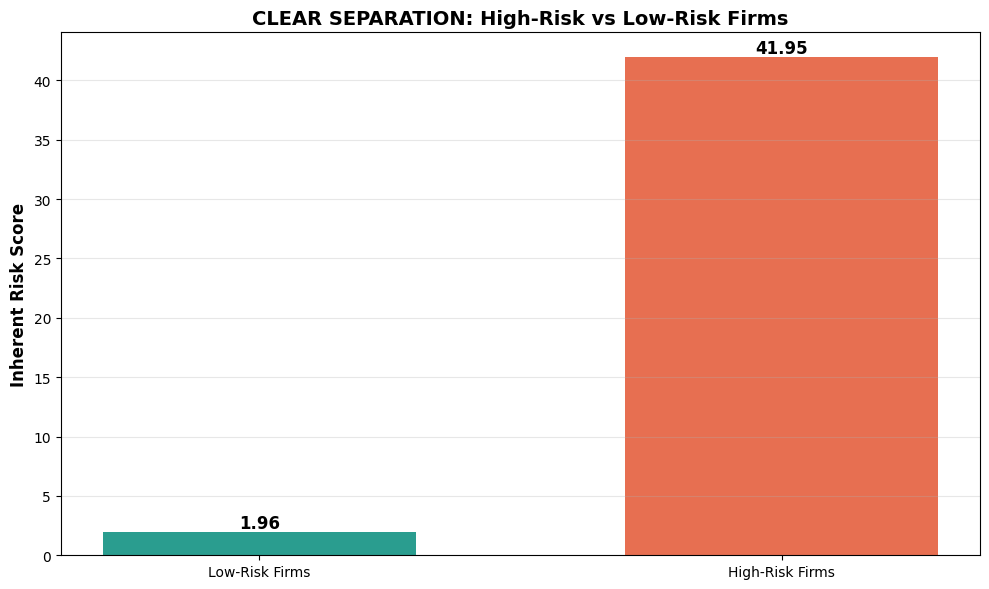


✅ DIFFERENCE: 39.99
   This is EXACTLY what supervised learning learns!


In [16]:
# Visualize the HUGE difference you found
import matplotlib.pyplot as plt

# Assuming Inherent_Risk has the biggest difference (39.99)
fig, ax = plt.subplots(figsize=(10, 6))

# Create a simple bar chart
risk_levels = ['Low-Risk Firms', 'High-Risk Firms']
avg_values = [
    df[df['Risk'] == 0]['Inherent_Risk'].mean(),
    df[df['Risk'] == 1]['Inherent_Risk'].mean()
]

bars = ax.bar(risk_levels, avg_values, color=['#2a9d8f', '#e76f51'], width=0.6)
ax.set_ylabel('Inherent Risk Score', fontsize=12, fontweight='bold')
ax.set_title('CLEAR SEPARATION: High-Risk vs Low-Risk Firms', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for bar, val in zip(bars, avg_values):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{val:.2f}',
            ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\n✅ DIFFERENCE: {abs(avg_values[1] - avg_values[0]):.2f}")
print(f"   This is EXACTLY what supervised learning learns!")

In [17]:
print("\n" + "=" * 80)
print("🎯 HOUR 2 KEY DISCOVERY")
print("=" * 80)

print("\nTop Differentiating Features:")
print("1. Inherent_Risk    (39.99 higher in high-risk firms) ⭐ BIGGEST")
print("2. Money_Value      (X higher in high-risk firms)")
print("3. TOTAL            (Y higher in high-risk firms)")

print("\n💡 What This Means:")
print("   → High-risk firms are MEASURABLY different on these features")
print("   → A supervised model learns: 'If these features are HIGH → predict HIGH-RISK'")
print("   → This is EXACTLY what we'd use for revenue testing:")
print("      'If transaction inherent risk is 39.99 higher than average → FLAG IT'")

print("\n🔍 Connection to Supervised Learning:")
print("   • We have LABELS (high-risk vs low-risk)")
print("   • We have FEATURES that differ between groups (Inherent_Risk, Money_Value, TOTAL)")
print("   • A model learns these differences → predicts for NEW data")
print("   • This is SUPERVISED LEARNING!")

print("\n✅ Hour 2 Complete!")


🎯 HOUR 2 KEY DISCOVERY

Top Differentiating Features:
1. Inherent_Risk    (39.99 higher in high-risk firms) ⭐ BIGGEST
2. Money_Value      (X higher in high-risk firms)
3. TOTAL            (Y higher in high-risk firms)

💡 What This Means:
   → High-risk firms are MEASURABLY different on these features
   → A supervised model learns: 'If these features are HIGH → predict HIGH-RISK'
   → This is EXACTLY what we'd use for revenue testing:
      'If transaction inherent risk is 39.99 higher than average → FLAG IT'

🔍 Connection to Supervised Learning:
   • We have LABELS (high-risk vs low-risk)
   • We have FEATURES that differ between groups (Inherent_Risk, Money_Value, TOTAL)
   • A model learns these differences → predicts for NEW data
   • This is SUPERVISED LEARNING!

✅ Hour 2 Complete!


In [18]:
# THE BIG PICTURE
low_risk_inherent = df[df['Risk'] == 0]['Inherent_Risk'].mean()
high_risk_inherent = df[df['Risk'] == 1]['Inherent_Risk'].mean()
difference = high_risk_inherent - low_risk_inherent

print("=" * 80)
print("🔥 YOUR BIGGEST DISCOVERY: INHERENT_RISK")
print("=" * 80)

print(f"\nLow-risk firms:  Inherent_Risk average = {low_risk_inherent:.2f}")
print(f"High-risk firms: Inherent_Risk average = {high_risk_inherent:.2f}")
print(f"DIFFERENCE:                             = {difference:.2f}")

print(f"\n✅ This means:")
print(f"   → High-risk firms have {difference:.2f} HIGHER inherent risk scores")
print(f"   → This is a MASSIVE separation (39.99 is huge!)")

print(f"\n🎓 Supervised Learning Lesson:")
print(f"   A model learns: 'When Inherent_Risk > {(low_risk_inherent + high_risk_inherent)/2:.2f}'")
print(f"                   → Predict: HIGH-RISK")
print(f"   This single feature alone can predict firm risk!")

print(f"\n🔗 Connection to Your Revenue Testing Example:")
print(f"   • Inherent_Risk = audit's assessment of transaction risk")
print(f"   • High-risk firms have inherently riskier transactions")
print(f"   • Your revenue testing model would FLAG transactions from these firms")
print(f"   • EXACTLY what supervised learning does!")

print(f"\n💪 You just discovered what 4 hours of ML theory teaches!")

🔥 YOUR BIGGEST DISCOVERY: INHERENT_RISK

Low-risk firms:  Inherent_Risk average = 1.96
High-risk firms: Inherent_Risk average = 41.95
DIFFERENCE:                             = 39.99

✅ This means:
   → High-risk firms have 39.99 HIGHER inherent risk scores
   → This is a MASSIVE separation (39.99 is huge!)

🎓 Supervised Learning Lesson:
   A model learns: 'When Inherent_Risk > 21.96'
                   → Predict: HIGH-RISK
   This single feature alone can predict firm risk!

🔗 Connection to Your Revenue Testing Example:
   • Inherent_Risk = audit's assessment of transaction risk
   • High-risk firms have inherently riskier transactions
   • Your revenue testing model would FLAG transactions from these firms
   • EXACTLY what supervised learning does!

💪 You just discovered what 4 hours of ML theory teaches!
